# Build a name generator from scratch
**Episode 01 · Coding companion**

Turn a file of names into a model that predicts and generates one character at a time.
Every model operation below is ordinary Python. Matplotlib only draws the charts.

**Our route:** data → pairs → counts → probabilities → generation → evaluation → experiments.

Open this notebook in VS Code, select the project `.venv` kernel, and run cells in order.
For a cold open, show the saved samples in section 11, then return here and restart the kernel.
The saved outputs are an executed reference; your live recording can reveal one cell at a time.

## 1 · Meet the data
A name is one example. We will learn patterns in spellings, not meanings or population frequencies.
The bundled file comes from Andrej Karpathy's **makemore** repository (MIT license), whose README
attributes the names to US Social Security data. See `data/README.md` for the pinned source.
Setup and chart styling are prepared utilities; the model itself is built below.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import random
import sys

# Support opening the notebook from the repository root or this episode folder.
candidates = [Path.cwd(), Path.cwd() / "episodes" / "01_names"]
if "__file__" in globals():
    candidates.insert(0, Path(__file__).resolve().parent)
EPISODE = next(path for path in candidates if (path / "data" / "names.txt").is_file())
sys.path.insert(0, str(EPISODE))
from visuals import style, plot_lengths, print_table, plot_counts, plot_row, plot_sweep

OUTPUT = EPISODE / "outputs"
OUTPUT.mkdir(exist_ok=True)
style()

In [2]:
data_bytes = (EPISODE / "data" / "names.txt").read_bytes()
provenance = json.loads((EPISODE / "data" / "provenance.json").read_text())
assert hashlib.sha256(data_bytes).hexdigest() == provenance["sha256"]
raw_names = data_bytes.decode("utf-8").splitlines()
assert all(name and name.isascii() and name.isalpha() and name.islower() for name in raw_names)

# One spelling per example; duplicates cannot leak across the split.
names = sorted(set(raw_names))
print(f"Source lines: {len(raw_names):,}")
print(f"Unique names: {len(names):,} | Duplicates removed: {len(raw_names) - len(names):,}")
print("Examples:", random.Random(7).sample(names, 12))
print(f"Lengths: {min(map(len, names))} to {max(map(len, names))} characters")

Source lines: 32,033
Unique names: 29,494 | Duplicates removed: 2,539
Examples: ['gunter', 'brexleigh', 'jaxston', 'neviah', 'alivya', 'anetta', 'torrion', 'leodan', 'arra', 'izekiel', 'marcella', 'amazing']
Lengths: 2 to 15 characters


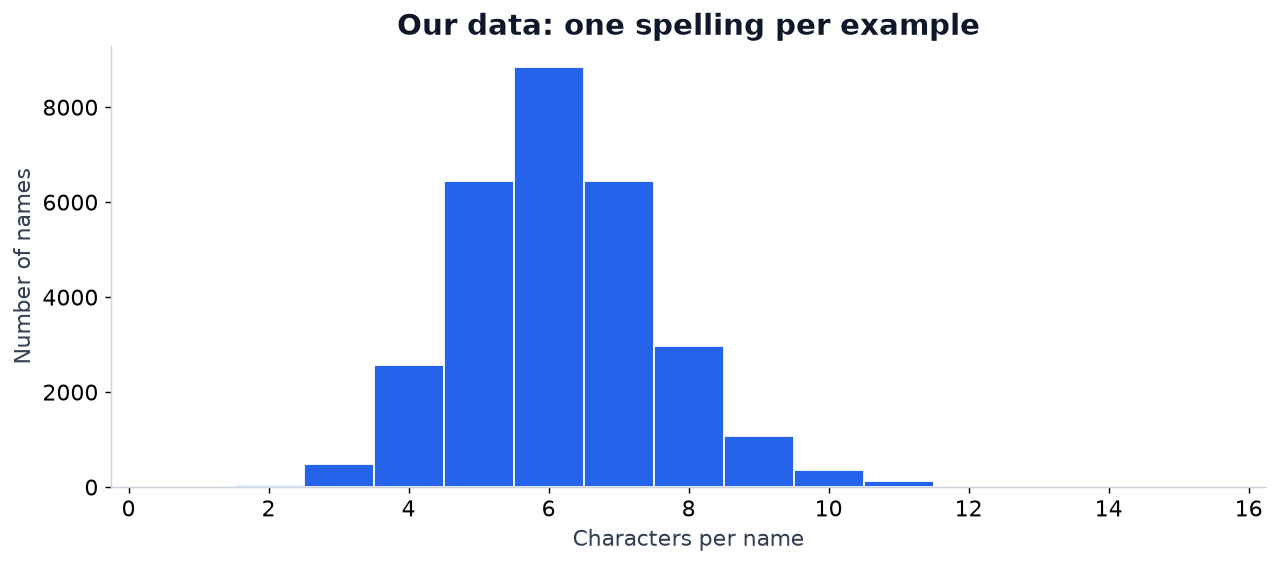

In [3]:
plot_lengths(names, OUTPUT)

## 2 · Reserve names the model will not train on
Shuffle whole names with a fixed seed, then use 80% for training, 10% for validation,
and the remainder for testing. Training supplies counts; validation chooses smoothing;
the test set provides the final measurement. We split before learning a vocabulary.

**Implementation detail:** separate random generators make the split independent of how
many samples we generate later. The seed is a reproducibility choice, not a model parameter.

In [4]:
shuffled = names.copy()
random.Random(42).shuffle(shuffled)
train_end = int(0.8 * len(shuffled))
validation_end = int(0.9 * len(shuffled))
train_names = shuffled[:train_end]
validation_names = shuffled[train_end:validation_end]
test_names = shuffled[validation_end:]

assert set(train_names).isdisjoint(validation_names)
assert set(train_names).isdisjoint(test_names)
assert set(validation_names).isdisjoint(test_names)
for label, split in [("Training", train_names), ("Validation", validation_names), ("Test", test_names)]:
    print(f"{label:12} {len(split):6,} names | {sum(len(n) + 1 for n in split):7,} predictions")

Training     23,595 names | 169,134 predictions
Validation    2,949 names |  21,141 predictions
Test          2,950 names |  21,053 predictions


## 3 · Characters, boundaries, and table addresses
Rows describe the **current token**: START and the letters.
Columns describe the **next token**: the letters and END.

We use separate row and column index maps. These integers are table addresses, so a letter's
row index need not equal its column index. When generating, we look up the sampled token's
row explicitly. START can never be predicted, and END has no outgoing row.
This implements the same allowed table as the theory episode.

In [5]:
START, END = "<START>", "<END>"

def make_vocabulary(training_names):
    characters = sorted(set("".join(training_names)))
    if not characters:
        raise ValueError("Training data must contain characters.")
    rows = [START] + characters
    columns = characters + [END]
    row_id = {token: index for index, token in enumerate(rows)}
    next_id = {token: index for index, token in enumerate(columns)}
    return rows, columns, row_id, next_id

In [6]:
row_tokens, next_tokens, row_id, next_id = make_vocabulary(train_names)
print("Rows:   ", row_tokens)
print("Columns:", next_tokens)
print("'a' row index:", row_id["a"], "| 'a' column index:", next_id["a"])
print(f"Table size: {len(row_tokens)} × {len(next_tokens)}")

Rows:    ['<START>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Columns: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '<END>']
'a' row index: 1 | 'a' column index: 0
Table size: 27 × 27


In [7]:
for label, split in [("Validation", validation_names), ("Test", test_names)]:
    unknown = sorted(set("".join(split)) - set(next_tokens))
    affected = sum(any(character not in next_id for character in name) for name in split)
    print(f"{label}: unknown characters = {unknown}; affected names = {affected}")
    if unknown:
        raise ValueError("Unknown characters need an explicit policy; this lesson never silently drops names.")

Validation: unknown characters = []; affected names = 0
Test: unknown characters = []; affected names = 0


Unknown-character checks audit compatibility; they do not change the vocabulary or split.
Smoothing can help an unseen **pair** of known characters. It cannot add a missing character.

In [8]:
def transitions(name):
    tokens = [START] + list(name) + [END]
    return list(zip(tokens, tokens[1:]))

print("Example from training:", train_names[0])
for current, target in transitions(train_names[0]):
    print(f"{current:>7} → {target:<7}  table[{row_id[current]}][{next_id[target]}]")

Example from training: aukai
<START> → a        table[0][0]
      a → u        table[1][20]
      u → k        table[21][10]
      k → a        table[11][0]
      a → i        table[1][8]
      i → <END>    table[9][26]


## 4 · Train by counting
Every adjacent pair adds one to one cell. A name with L characters contributes L + 1
predictions: START → first character, internal pairs, and last character → END.
Names are processed separately, so the end of one never connects to the start of another.

In [9]:
def count_bigrams(examples, row_id, next_id):
    counts = [[0 for _ in next_id] for _ in row_id]
    for name in examples:
        for current, target in transitions(name):
            counts[row_id[current]][next_id[target]] += 1
    return counts

counts = count_bigrams(train_names, row_id, next_id)
assert sum(map(sum, counts)) == sum(len(name) + 1 for name in train_names)
assert sum(counts[row_id[START]]) == len(train_names)
assert sum(row[next_id[END]] for row in counts) == len(train_names)
print(f"Counted {sum(map(sum, counts)):,} transitions from {len(train_names):,} training names.")

Counted 169,134 transitions from 23,595 training names.


Most frequent tokens after 'a':
  <END>: 5,215
      n: 4,080
      r: 2,394
      l: 1,925
      h: 1,775
      y: 1,542
      i: 1,239
      m: 1,187


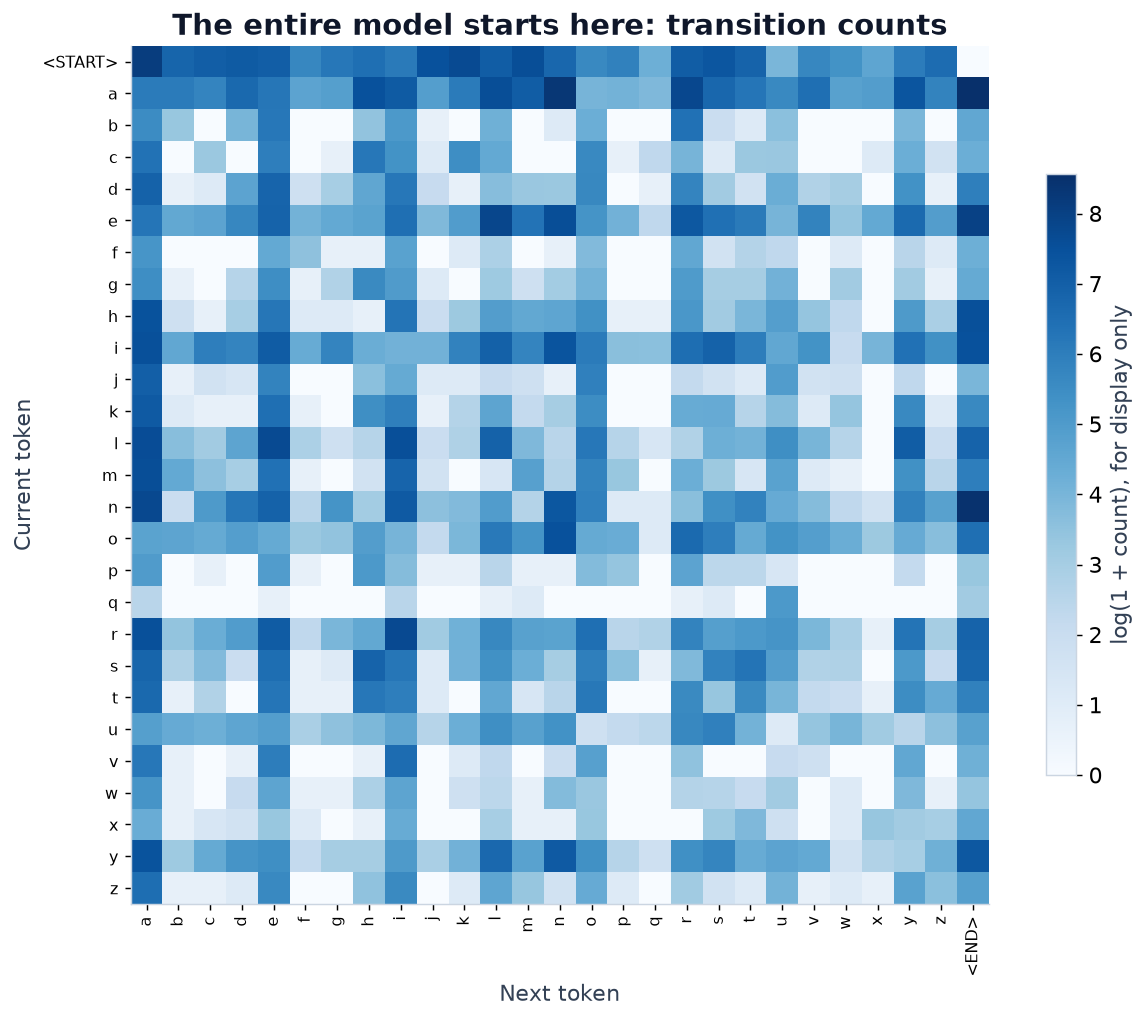

In [10]:
current = "a"
ranked_counts = sorted(zip(next_tokens, counts[row_id[current]]), key=lambda item: item[1], reverse=True)
print(f"Most frequent tokens after {current!r}:")
for target, count in ranked_counts[:8]:
    print(f"{target:>7}: {count:,}")
plot_counts(counts, row_tokens, next_tokens, OUTPUT)

## 5 · Counts become probabilities
Divide each row by its own total. The resulting row answers: "Given this current token,
how likely is each next token?" Counting and normalization finish training this model.

In [11]:
def normalize(counts):
    probabilities = []
    for row in counts:
        total = sum(row)
        if total <= 0:
            raise ValueError("Cannot normalize an empty row; collect evidence or use smoothing.")
        probabilities.append([count / total for count in row])
    return probabilities

Every probability row sums to 1.
P(<END> | a) = 5215/25663 = 0.2032
P(n | a) = 4080/25663 = 0.1590
P(r | a) = 2394/25663 = 0.0933
P(l | a) = 1925/25663 = 0.0750
P(h | a) = 1775/25663 = 0.0692


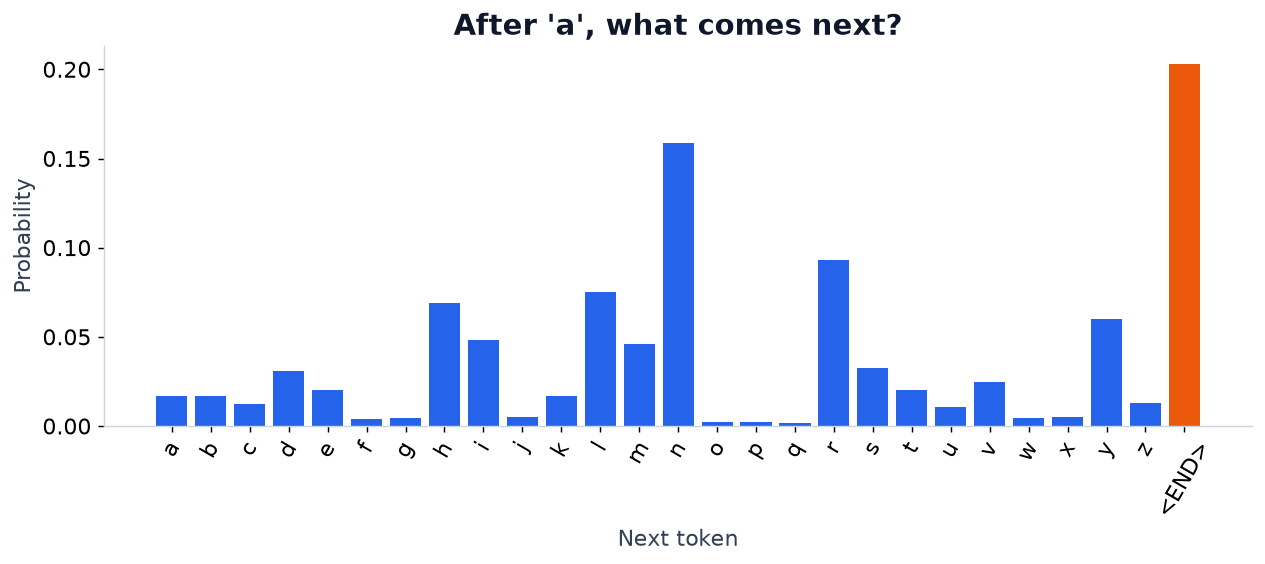

In [12]:
probabilities = normalize(counts)
assert all(math.isclose(sum(row), 1.0) for row in probabilities)
print("Every probability row sums to 1.")
for target, count in ranked_counts[:5]:
    p = probabilities[row_id["a"]][next_id[target]]
    print(f"P({target} | a) = {count}/{sum(counts[row_id['a']])} = {p:.4f}")
plot_row(probabilities, row_id, next_tokens, "a", OUTPUT)

## 6 · Make it generate
Begin at START. Choose a next token, then use that token as the next context.
Stop when the model selects END. **Greedy** chooses the most probable next token;
**sampling** makes a weighted random choice. Greedy does not find the globally most likely name.

A maximum length bounds the loop. Hitting it is reported as truncation; it does not mean the
model predicted END. Ties in greedy decoding follow the fixed column order.

In [13]:
def generate(probabilities, row_id, next_tokens, rng, greedy=False, max_length=24):
    if max_length < 1:
        raise ValueError("max_length must be positive.")
    current = START
    letters = []
    for _ in range(max_length):
        weights = probabilities[row_id[current]]
        if greedy:
            index = max(range(len(weights)), key=lambda i: weights[i])
            target = next_tokens[index]
        else:
            target = rng.choices(next_tokens, weights=weights, k=1)[0]
        if target == END:
            return "".join(letters), True
        letters.append(target)
        current = target
    return "".join(letters), False

In [14]:
sample_rng = random.Random(2026)
greedy_name, ended = generate(probabilities, row_id, next_tokens, sample_rng, greedy=True)
print("Greedy:", repr(greedy_name), "|", "END selected" if ended else "LENGTH CAP")
print("\nFirst 100 weighted samples (no filtering):")
for _ in range(100):
    name, ended = generate(probabilities, row_id, next_tokens, sample_rng)
    print(f"{name!r:28} {'END selected' if ended else 'LENGTH CAP'}")

Greedy: 'a' | END selected

First 100 weighted samples (no filtering):
'ann'                        END selected
'aiootlostomia'              END selected
'jorole'                     END selected
'vi'                         END selected
'kamifi'                     END selected
'miavenionan'                END selected
'li'                         END selected
'de'                         END selected
'jeajadozarine'              END selected
'men'                        END selected
'zin'                        END selected
'ezen'                       END selected
'jalasonnn'                  END selected
'den'                        END selected
'ri'                         END selected
'sh'                         END selected
'avinn'                      END selected
'y'                          END selected
'jaliayliaar'                END selected
'azarr'                      END selected
'micerr'                     END selected
'kokar'                      END selected
'siat

## 7 · Measure predictions on supplied names
Evaluation follows the real characters of each supplied name; it does not sample.
For every transition, look up p and add −ln(p). Divide the **total** penalty by the
**total** number of predictions, including END. This is nats per prediction; lower is better.

We accumulate log penalties to avoid multiplying many tiny probabilities.
A zero probability contributes infinite NLL. We report it honestly, without adding a hidden epsilon.

In [15]:
def evaluate(examples, probabilities, row_id, next_id):
    unknown = sorted(set("".join(examples)) - set(next_id))
    if unknown:
        raise ValueError(f"Unknown characters: {unknown}")
    total_nll = 0.0
    predictions = 0
    zero_predictions = 0
    for name in examples:
        for current, target in transitions(name):
            p = probabilities[row_id[current]][next_id[target]]
            total_nll += -math.log(p) if p > 0 else math.inf
            predictions += 1
            zero_predictions += int(p == 0)
    if predictions == 0:
        raise ValueError("Evaluation needs at least one example.")
    return {"nll": total_nll / predictions, "predictions": predictions,
            "zero_predictions": zero_predictions}

In [16]:
for label, split in [("Training", train_names), ("Validation", validation_names)]:
    result = evaluate(split, probabilities, row_id, next_id)
    print(f"{label:12} NLL={result['nll']:.6f} | zero-probability predictions={result['zero_predictions']}")

Training     NLL=2.452920 | zero-probability predictions=0
Validation   NLL=inf | zero-probability predictions=8


### One-minute bridge back to the theory
Reuse our functions with `anna` and `ava`. Only this small check should reproduce the theory's
numbers; the real dataset has its own probabilities and loss values.

In [17]:
toy_rows, toy_columns, toy_row_id, toy_next_id = make_vocabulary(["anna", "ava"])
toy_counts = count_bigrams(["anna", "ava"], toy_row_id, toy_next_id)
toy_probabilities = normalize(toy_counts)
print_table(toy_counts, toy_rows, toy_columns)
path_probability = 1.0
for current, target in transitions("ana"):
    p = toy_probabilities[toy_row_id[current]][toy_next_id[target]]
    path_probability *= p
    print(f"{current:>7} → {target:<7} p={p:.2f}  penalty={-math.log(p):.6f}")
toy_score = evaluate(["ana"], toy_probabilities, toy_row_id, toy_next_id)
assert math.isclose(path_probability, 0.0625)
assert math.isclose(toy_score["nll"], math.log(2))
print(f"P(ana)={path_probability:.4f} | average NLL={toy_score['nll']:.6f}")

current \ next          a        n        v    <END>
<START>                 2        0        0        0
a                       0        1        1        2
n                       1        1        0        0
v                       1        0        0        0
<START> → a       p=1.00  penalty=-0.000000
      a → n       p=0.25  penalty=1.386294
      n → a       p=0.50  penalty=0.693147
      a → <END>   p=0.50  penalty=0.693147
P(ana)=0.0625 | average NLL=0.693147


## 8 · Lower than what? Two baselines
**Uniform:** every allowed next token gets the same probability.
**Unigram:** count next-token frequencies across training, ignoring the current token.
END is an outcome for both baselines; START is not. Every model uses the same evaluation pairs.

In [18]:
outcomes = len(next_tokens)
uniform = [[1 / outcomes for _ in next_tokens] for _ in row_tokens]
unigram_counts = [sum(row[column] for row in counts) for column in range(outcomes)]
unigram_row = [count / sum(unigram_counts) for count in unigram_counts]
unigram = [unigram_row.copy() for _ in row_tokens]

validation_baselines = {}
for label, table in [("Uniform", uniform), ("Unigram", unigram), ("Bigram, k=0", probabilities)]:
    result = evaluate(validation_names, table, row_id, next_id)
    validation_baselines[label] = result["nll"]
    print(f"{label:16} validation NLL = {result['nll']:.6f}")
assert math.isclose(validation_baselines["Uniform"], math.log(outcomes))

Uniform          validation NLL = 3.295837
Unigram          validation NLL = 2.823959
Bigram, k=0      validation NLL = inf


## 9 · An unseen pair, then smoothing
In the toy model, `v` and `n` are known characters but `v → n` never occurred.
`avna` therefore receives probability zero. Add-k smoothing gives each allowed cell a
pseudo-count k and then normalizes: **(count + k) / (row total + k × number of outcomes)**.
This spreads some probability away from observed pairs to unseen pairs.

In [19]:
print("Unsmoothed avna:", evaluate(["avna"], toy_probabilities, toy_row_id, toy_next_id))

def smooth(counts, k):
    if not math.isfinite(k) or k < 0:
        raise ValueError("k must be finite and non-negative.")
    return normalize([[count + k for count in row] for row in counts])

toy_smoothed = smooth(toy_counts, k=1.0)
print("Smoothed v row:")
print_table([toy_smoothed[toy_row_id["v"]]], ["v"], toy_columns, decimals=2)
print("Smoothed avna:", evaluate(["avna"], toy_smoothed, toy_row_id, toy_next_id))

Unsmoothed avna: {'nll': inf, 'predictions': 5, 'zero_predictions': 1}
Smoothed v row:
current \ next          a        n        v    <END>
v                    0.40     0.20     0.20     0.20
Smoothed avna: {'nll': 1.1536641991587544, 'predictions': 5, 'zero_predictions': 0}


## 10 · Choose k with an experiment
Our candidate grid is a project choice, fixed before examining test loss.
Compare training and validation NLL. Select the best **validation** value among these candidates;
this is not a claim that we found the best possible k. The original counts stay unchanged.

       k      train NLL   validation NLL
       0       2.452920              inf
   0.001       2.452921         2.458584


    0.01       2.452927         2.457718


    0.03       2.452941         2.457314


     0.1       2.452989         2.456902


     0.3       2.453138         2.456622


       1       2.453748         2.456749


       3       2.455848         2.458437
      10       2.464295         2.466627


     100       2.560509         2.562910

Selected k=0.3 using validation only.


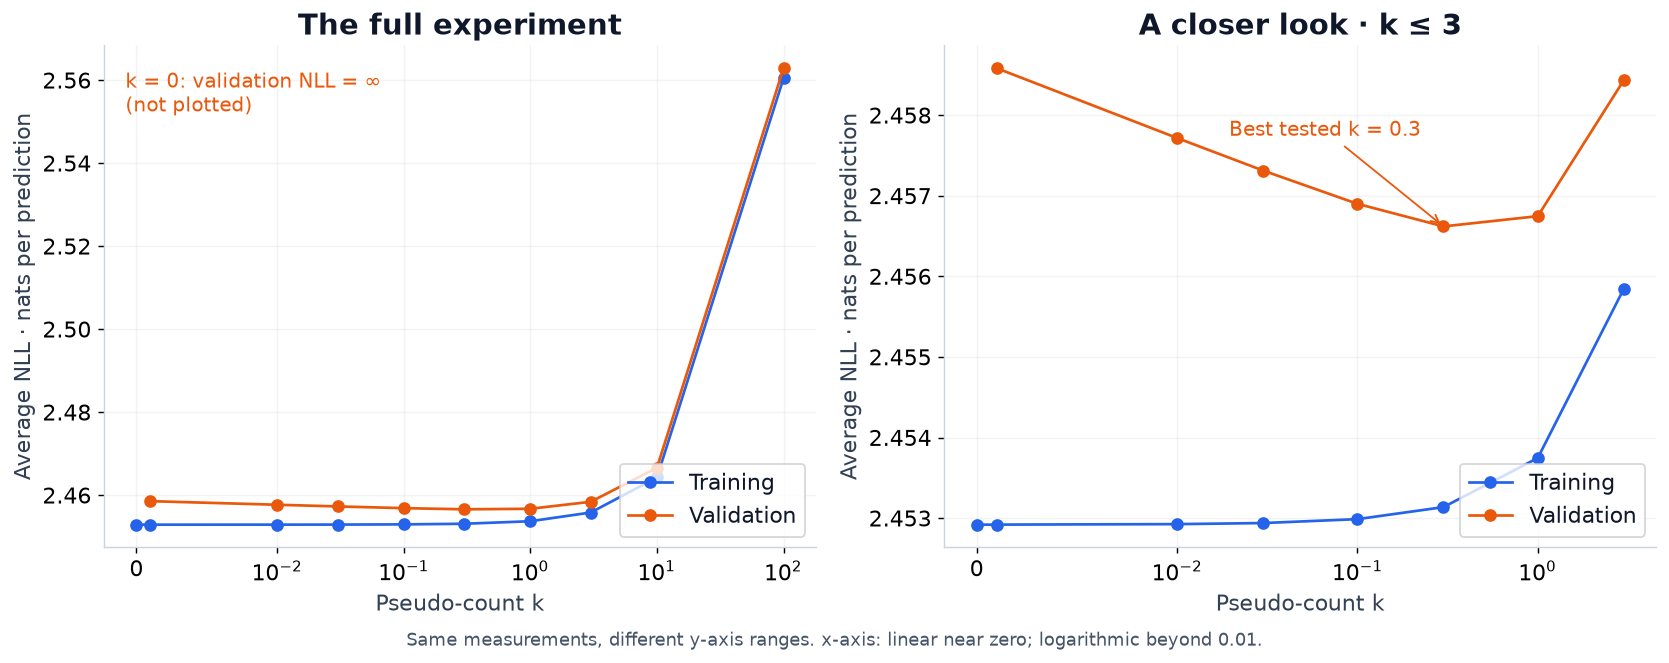

In [20]:
k_values = [0.0, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0]
sweep = []
print(f"{'k':>8} {'train NLL':>14} {'validation NLL':>16}")
for k in k_values:
    table = smooth(counts, k)
    train_nll = evaluate(train_names, table, row_id, next_id)["nll"]
    validation_nll = evaluate(validation_names, table, row_id, next_id)["nll"]
    sweep.append({"k": k, "train_nll": train_nll, "validation_nll": validation_nll})
    print(f"{k:8g} {train_nll:14.6f} {validation_nll:16.6f}")

best = min(sweep, key=lambda result: result["validation_nll"])
best_k = best["k"]
final_probabilities = smooth(counts, best_k)
print(f"\nSelected k={best_k:g} using validation only.")
plot_sweep(sweep, OUTPUT)

In [21]:
# A numerical checkpoint: overwhelming smoothing approaches the uniform baseline.
almost_uniform = smooth(counts, 1e9)
large_k_nll = evaluate(validation_names, almost_uniform, row_id, next_id)["nll"]
assert math.isclose(large_k_nll, math.log(outcomes), abs_tol=1e-5)
print(f"Huge-k NLL: {large_k_nll:.6f} | uniform ln({outcomes}): {math.log(outcomes):.6f}")

Huge-k NLL: 3.295836 | uniform ln(27): 3.295837


## 11 · Use the model, inspect its limitations
These are the first 100 samples with a fixed seed. We do not filter out short, odd, repeated,
empty, or truncated results. Smoothing permits START → END, so an empty sample is possible.
A sample matching training is labeled; an unmatched spelling is not proof it is a new real name.

In [22]:
sample_rng = random.Random(2026)
training_spellings = set(train_names)
samples = []
for _ in range(100):
    name, ended = generate(final_probabilities, row_id, next_tokens, sample_rng)
    samples.append({"name": name, "ended": ended, "in_training": name in training_spellings})
    print(f"{name!r:28} {'END' if ended else 'CAP':4} | {'seen in training' if name in training_spellings else 'not in training'}")

'ann'                        END  | seen in training
'aiootlostomia'              END  | not in training
'jorole'                     END  | not in training
'vi'                         END  | not in training
'kamifi'                     END  | not in training
'miavenionan'                END  | not in training
'li'                         END  | not in training
'de'                         END  | not in training
'jeajadozarine'              END  | not in training
'men'                        END  | not in training
'zin'                        END  | seen in training
'ezen'                       END  | not in training
'jalasonnn'                  END  | not in training
'den'                        END  | not in training
'ri'                         END  | not in training
'sh'                         END  | not in training
'avinn'                      END  | not in training
'y'                          END  | not in training
'jaliayliaar'                END  | not in training
'azarr'   

In [23]:
greedy_name, greedy_ended = generate(final_probabilities, row_id, next_tokens,
                                     random.Random(2026), greedy=True)
print("Greedy:", repr(greedy_name), "|", "END" if greedy_ended else "LENGTH CAP")

Greedy: 'a' | END


The context limitation is visible in the lookup itself: prefixes ending with the same character
use exactly the same next-token row. For `an` and `marian`, everything before the final `n`
is discarded. Longer context is the next experiment in the series.

In [24]:
for prefix in ["an", "marian"]:
    row = final_probabilities[row_id[prefix[-1]]]
    top = sorted(zip(next_tokens, row), key=lambda item: item[1], reverse=True)[:5]
    print(f"Prefix {prefix!r:10} → context {prefix[-1]!r} → {[(t, round(p, 4)) for t, p in top]}")

Prefix 'an'       → context 'n' → [('<END>', 0.355), ('a', 0.17), ('n', 0.1054), ('i', 0.0958), ('e', 0.0747)]
Prefix 'marian'   → context 'n' → [('<END>', 0.355), ('a', 0.17), ('n', 0.1054), ('i', 0.0958), ('e', 0.0747)]


## 12 · Final measurement
k is now fixed. Evaluate the test split for the final report; keep training counts as they were.
Reading test results repeatedly while changing choices would turn this into another validation set.

**Reporting contract:** bundled unique name spellings; deterministic 80/10/10 split, seed 42;
training-only character vocabulary; separate START/END; END included; total NLL divided by
total predictions; natural logs. Comparisons to another episode require these conventions to match.

In [25]:
test_results = {}
for label, table in [("Uniform", uniform), ("Unigram", unigram), ("Smoothed bigram", final_probabilities)]:
    result = evaluate(test_names, table, row_id, next_id)
    test_results[label] = result
    print(f"{label:18} test NLL={result['nll']:.6f} | {result['predictions']:,} predictions")

Uniform            test NLL=3.295837 | 21,053 predictions
Unigram            test NLL=2.818510 | 21,053 predictions
Smoothed bigram    test NLL=2.460499 | 21,053 predictions
